In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.special 

# 6.1 Spontaneous Magnetization

In [2]:
# Reuse definitions from exercise 5

def H2d(J,x):
    return -J*(np.roll(x,-1, axis=1)*x + np.roll(x,1, axis=1)*x +np.roll(x,-1, axis=0)*x + np.roll(x,1, axis=0)*x).sum()

def delH2d(J,sigma,x):
    a = x[0]
    b = x[1]
    delH = 0
    if a == len(sigma)-1:
        delH = sigma[a,b]*sigma[a-1,b] + sigma[a,b]*sigma[0,b]
    else:
        delH = sigma[a,b]*sigma[a-1,b] + sigma[a,b]*sigma[a+1,b]
    if b == len(sigma.T)-1:
        delH = delH + sigma[a,b]*sigma[a,b-1] + sigma[a,b]*sigma[a,0]
    else:
        delH = delH + sigma[a,b]*sigma[a,b-1] + sigma[a,b]*sigma[a,b+1]
        
    return 2*J*delH

def MC_right(J,start,steps):

    current = start
    m = np.zeros(steps)
    m_abs = np.zeros(steps)
    eps = np.zeros(steps)

    
    for s in range(steps):
        #for each step choose position
        x = np.random.choice(len(start), 2)

        if np.random.uniform(low=0, high=1) < np.exp(-delH2d(J,current,x)): # accepting condition
            # if accepted flip a spin
            new = current
            new[x[0],x[1]] = -current[x[0],x[1]]

        else:
            # else keep current spinconfiguration
            new = current
        current = new
        #calculate M/N
        
        m[s] = current.sum()/(len(start))**2
        m_abs[s] = np.abs(m[s])
        eps[s] = H2d(J,current)/(2*(len(start))**2)

    return m, m_abs, eps 

In [3]:

def checkerboard(dim):
    x = np.ones((dim,dim))
    i = np.arange(len(x))%2
    j = np.arange(len(x.T))%2
    for q in range(len(j)):
        for h in range(len(i)):  
            if i[h] == j[q]:
                x[h,q]=-1
    return x


In [4]:
Jc = 0.5*np.log(1+np.sqrt(2))

J = np.array([0.1, 0.2, Jc, 0.7, 0.8])

start_4 = checkerboard(4)
m_abs_4 = [MC_right(J[c],start_4,10000)[1] for c in range(len(J))]

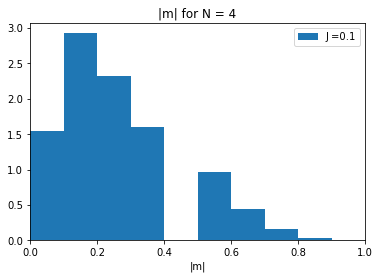

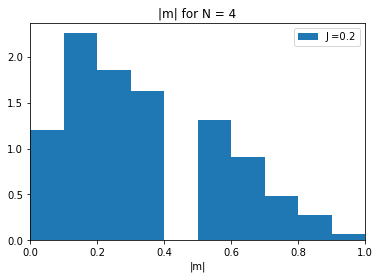

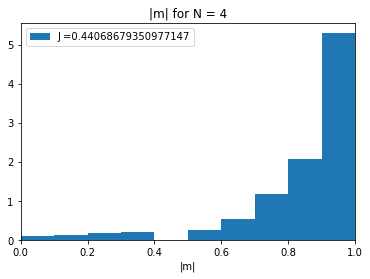

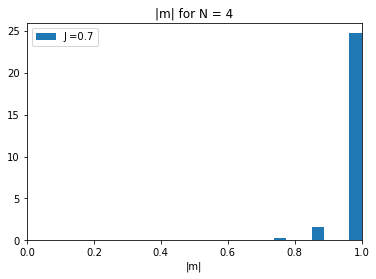

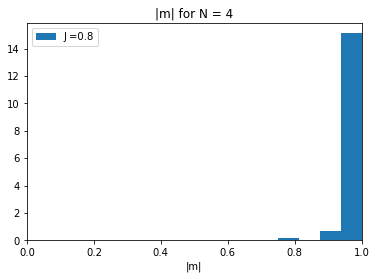

In [5]:
for c in range(len(J)):
    plt.hist(m_abs_4[c], label=f"J ={J[c]}",density = True)
    plt.legend()
    plt.title('|m| for N = 4')
    plt.xlim(0,1)
    plt.xlabel('|m|')
    plt.show()

In [6]:
start_8 = checkerboard(8)
m_abs_8 = [MC_right(J[c],start_8,10000)[1] for c in range(len(J))]

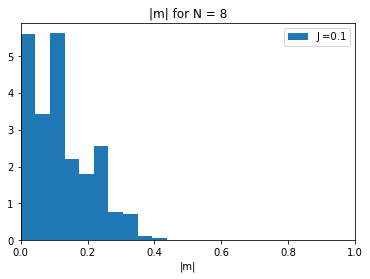

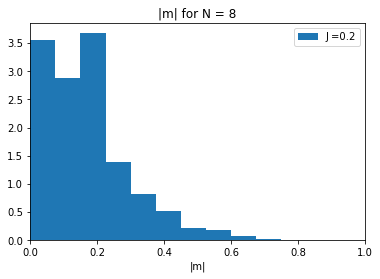

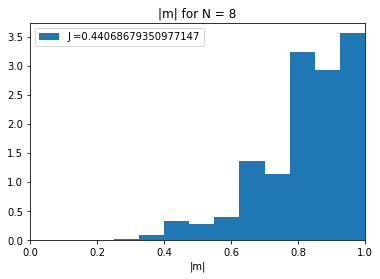

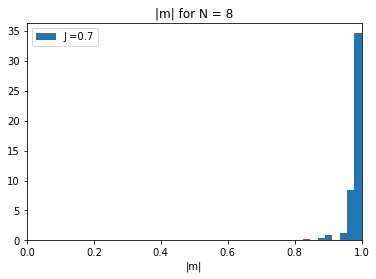

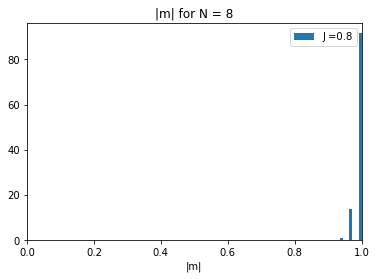

In [9]:
for c in range(len(J)):
    plt.hist(m_abs_8[c], label=f"J ={J[c]}",density = True)
    plt.legend()
    plt.title('|m| for N = 8')
    plt.xlim(0,1)
    plt.xlabel('|m|')
    plt.show()

In [8]:
start_12 = checkerboard(12)
m_abs_12 = [MC_right(J[c],start_12,10000)[1] for c in range(len(J))]

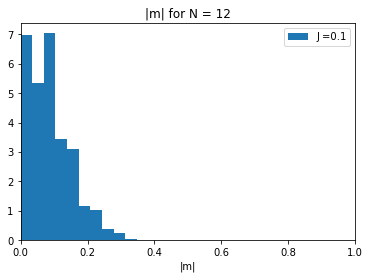

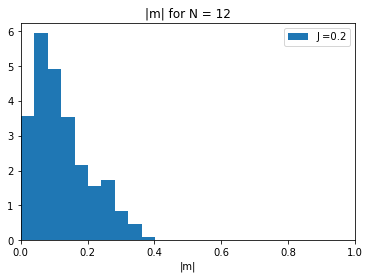

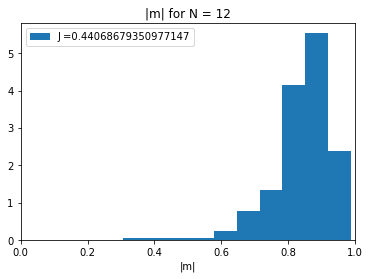

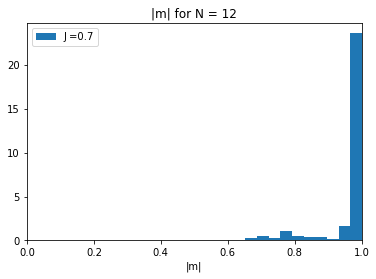

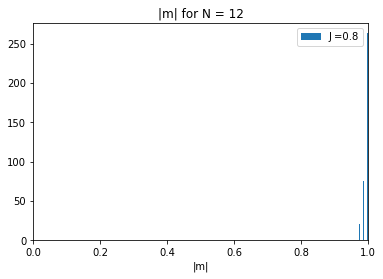

In [10]:
for c in range(len(J)):
    plt.hist(m_abs_12[c], label=f"J ={J[c]}",density = True)
    plt.legend()
    plt.title('|m| for N = 12')
    plt.xlim(0,1)
    plt.xlabel('|m|')
    plt.show()

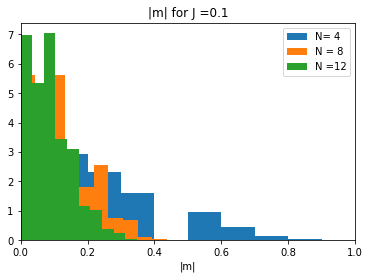

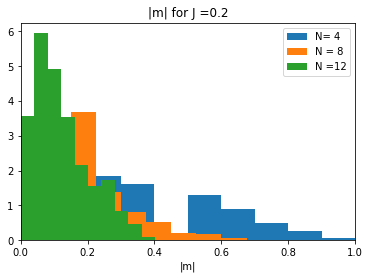

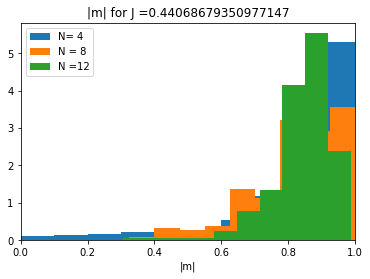

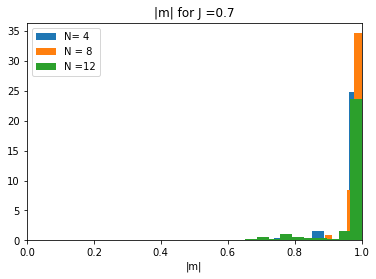

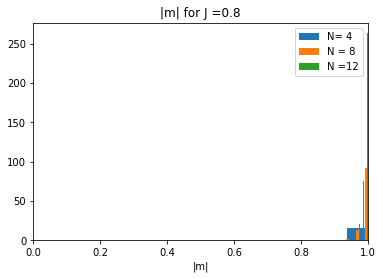

In [11]:
for c in range(len(J)):
    plt.hist(m_abs_4[c], label=f"N= 4",density = True)
    plt.hist(m_abs_8[c], label=f"N = 8",density = True)
    plt.hist(m_abs_12[c], label=f"N =12",density = True)
    plt.title(f"|m| for J ={J[c]}")
    plt.xlabel('|m|')
    plt.legend()
    plt.xlim(0,1)
    plt.show()

# J< Jc near 0, J> Jc going to 1, N higher - >need more steps

# 6.2 Scanning $J$

In [12]:
def m(J):
    m = np.zeros(len(J))
    for t in range(len(J)):
        Jc = 0.5*np.log(1+np.sqrt(2))
        if J[t] > Jc:
            m[t] = (1- 1/(np.sinh(2*J[t])**4))**(1/8)
        else:
            m[t] = 0
    return m

def coth(x):
    return np.cosh(x)/np.sinh(x)

def sech(x):
    return 1/np.cosh(x)

def epsilon(J):
    return -J*coth(2*J)*(1+ 2/np.pi*(2*np.tanh(2*J)**2-1)*scipy.special.ellipk(4*sech(2*J)**2*np.tanh(2*J)**2))

In [13]:
J_2 = np.arange(1,4.1,0.1)
JM = np.linspace(1,4,1000)
steps = 2000

m_abs_4 = np.array([MC_right(1/J_2[c], start_4,steps)[1] for c in range(len(J_2))])
m_abs_4_mean = m_abs_4.mean(axis=1)
m_abs_4_uncert = m_abs_4.std(axis=1)
m_abs_8 = np.array([MC_right(1/J_2[c], start_8,steps)[1] for c in range(len(J_2))])
m_abs_8_mean = m_abs_8.mean(axis=1)
m_abs_8_uncert = m_abs_8.std(axis=1)
m_abs_12 = np.array([MC_right(1/J_2[c], start_12,steps)[1] for c in range(len(J_2))])
m_abs_12_mean = m_abs_12.mean(axis=1)
m_abs_12_uncert = np.sqrt(m_abs_12.std(axis=1))

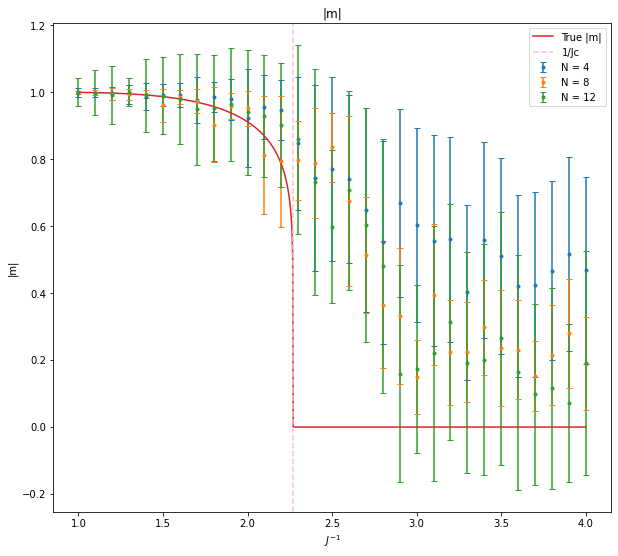

In [14]:

fig,ax =plt.subplots(figsize=(10,9))
ax.errorbar(J_2, m_abs_4_mean, yerr = m_abs_4_uncert, linestyle =' ', capsize=3, marker ='.', label = "N = 4")
ax.errorbar(J_2, m_abs_8_mean, yerr = m_abs_8_uncert, linestyle =' ', capsize=3, marker ='.', label = "N = 8")
ax.errorbar(J_2, m_abs_12_mean, yerr = m_abs_12_uncert, linestyle =' ', capsize=3, marker ='.', label = "N = 12")
ax.plot(JM,m(1/JM), label = "True |m|")
ax.axvline(1/Jc, linestyle = '--', color = 'pink', label = '1/Jc')
ax.set_title('|m|')
ax.legend()
ax.set_xlabel('$J^{-1}$')
ax.set_ylabel('|m|')
plt.show()

In [18]:

eps_M = np.linspace(1,4,1000)
steps = 2000

eps_4 = np.array([MC_right(1/J_2[c], start_4,steps)[2] for c in range(len(J_2))])
eps_4_mean = eps_4.mean(axis=1)
eps_4_uncert = eps_4.std(axis=1)
eps_8 = np.array([MC_right(1/J_2[c], start_8,steps)[2] for c in range(len(J_2))])
eps_8_mean = eps_8.mean(axis=1)
eps_8_uncert = eps_8.std(axis=1)
eps_12 = np.array([MC_right(1/J_2[c], start_12,steps)[2] for c in range(len(J_2))])
eps_12_mean = eps_12.mean(axis=1)
eps_12_uncert = eps_12.std(axis=1)

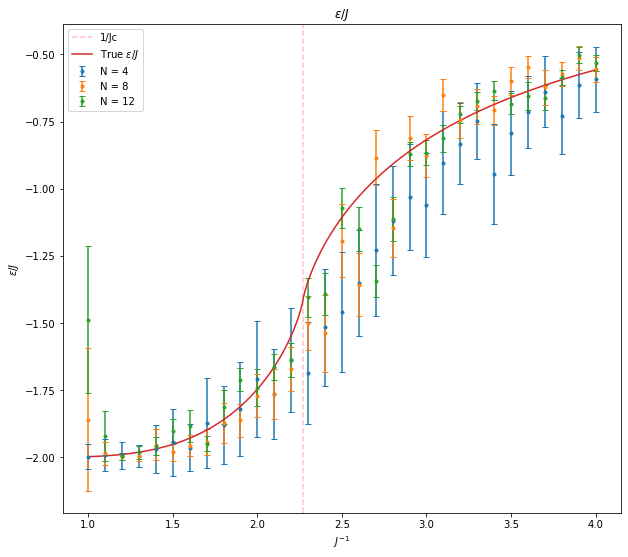

In [19]:
fig,ax =plt.subplots(figsize=(10,9))
ax.errorbar(J_2, eps_4_mean*J_2, yerr = eps_4_uncert, linestyle =' ', capsize=3, marker ='.', label = "N = 4")
ax.errorbar(J_2, eps_8_mean*J_2, yerr = eps_8_uncert, linestyle =' ', capsize=3, marker ='.', label = "N = 8")
ax.errorbar(J_2, eps_12_mean*J_2, yerr = eps_12_uncert, linestyle =' ', capsize=3, marker ='.', label = "N = 12")
ax.axvline(1/Jc, linestyle = '--', color = 'pink', label = '1/Jc')
ax.plot(JM,epsilon(1/JM)*JM, label = "True $\epsilon/J$")
ax.set_title('$\epsilon/J$')
ax.legend()
ax.set_xlabel('$J^{-1}$')
ax.set_ylabel('$\epsilon/J$')
plt.show()

# 6.3 The Spin-Spin Correlation Function

What value should $C(0)$ take : $C(0) = \frac{1}{\Lambda}\sum{C_{x,x}} = \frac{1}{\Lambda}\sum{\frac{1}{Z} \sum_\sigma e^{-\beta H} \sigma_x \sigma_x} = \frac{1}{\Lambda}\sum{\frac{1}{Z} \sum_\sigma e^{-\beta H}} =\frac{1}{\Lambda} \Lambda =1 $


In [20]:

def fft(timeseries):
    steps = len(timeseries)
    series = timeseries
    # fft for rows
    Cvert = np.fft.ifft(np.fft.fft(series) * np.fft.ifft(series)).real
    # fft for columns
    Choriz = np.fft.ifft(np.fft.fft(series.T) * np.fft.ifft(series.T)).real
    C = (Cvert.mean(axis=0) + Choriz.mean(axis=0))/2
    C_err =(Cvert.std(axis=0)+Choriz.std(axis=0))/2
    return C / C[0],C_err



In [21]:
def MC_fft(J,start,steps):

    current = start
    
    for s in range(steps):
        #for each step choose position
        x = np.random.choice(len(start), 2)

        if np.random.uniform(low=0, high=1) < np.exp(-delH2d(J,current,x)): # accepting condition
            # if accepted flip a spin
            new = current
            new[x[0],x[1]] = -current[x[0],x[1]]

        else:
            # else keep current spinconfiguration
            new = current
        current = new
        
        # Calcuate for each current C
    C,C_err= fft(current)

    return C, C_err

In [22]:
steps =10000
C1_4, C1_4_err = MC_fft(1,start_4,steps)
C2_4, C2_4_err = MC_fft(1/2,start_4,steps)
C3_4, C3_4_err = MC_fft(1/3,start_4,steps)
C4_4, C4_4_err = MC_fft(1/4,start_4,steps)
C1_8, C1_8_err = MC_fft(1,start_8,steps)
C2_8, C2_8_err = MC_fft(1/2,start_8,steps)
C3_8, C3_8_err = MC_fft(1/3,start_8,steps)
C4_8, C4_8_err = MC_fft(1/4,start_8,steps)
C1_12, C1_12_err = MC_fft(1,start_12,steps)
C2_12, C2_12_err = MC_fft(1/2,start_12,steps)
C3_12, C3_12_err = MC_fft(1/3,start_12,steps)
C4_12, C4_12_err = MC_fft(1/4,start_12,steps)


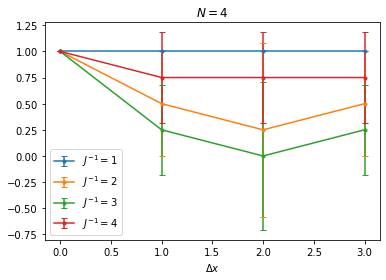

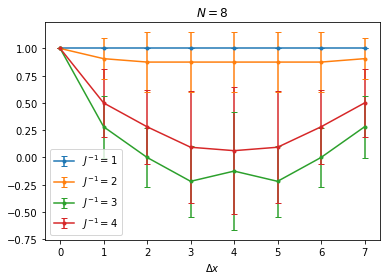

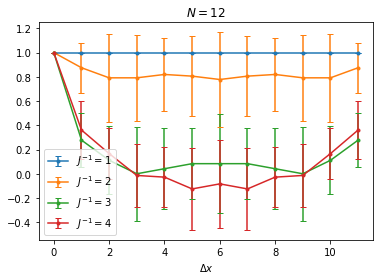

In [26]:
x_4 = [0,1,2,3]
plt.errorbar(x_4, C1_4, yerr = C1_4_err ,label = '$J^{-1} =1$', marker ='.', capsize = 3)
plt.errorbar(x_4, C2_4, yerr = C2_4_err ,label = '$J^{-1} =2$', marker ='.', capsize = 3)
plt.errorbar(x_4, C3_4, yerr = C3_4_err ,label = '$J^{-1} =3$', marker ='.', capsize = 3)
plt.errorbar(x_4, C4_4, yerr = C4_4_err ,label = '$J^{-1} =4$', marker ='.', capsize = 3)
plt.xlabel('$\Delta x$')
plt.title('$N = 4$')
plt.legend()
plt.show()
x_8 = [0,1,2,3,4,5,6,7]
plt.errorbar(x_8, C1_8, yerr = C1_8_err ,label = '$J^{-1} =1$', marker ='.', capsize = 3)
plt.errorbar(x_8, C2_8, yerr = C2_8_err ,label = '$J^{-1} =2$', marker ='.', capsize = 3)
plt.errorbar(x_8, C3_8, yerr = C3_8_err ,label = '$J^{-1} =3$', marker ='.', capsize = 3)
plt.errorbar(x_8, C4_8, yerr = C4_8_err ,label = '$J^{-1} =4$', marker ='.', capsize = 3)
plt.xlabel('$\Delta x$')
plt.title('$N = 8$')
plt.legend()
plt.show()
x_12 = [0,1,2,3,4,5,6,7,8,9,10,11]
plt.errorbar(x_12, C1_12, yerr = C1_12_err ,label = '$J^{-1} =1$', marker ='.', capsize = 3)
plt.errorbar(x_12, C2_12, yerr = C2_12_err ,label = '$J^{-1} =2$', marker ='.', capsize = 3)
plt.errorbar(x_12, C3_12, yerr = C3_12_err ,label = '$J^{-1} =3$', marker ='.', capsize = 3)
plt.errorbar(x_12, C4_12, yerr = C4_12_err ,label = '$J^{-1} =4$', marker ='.', capsize = 3)
plt.xlabel('$\Delta x$')
plt.title('$N = 12$')
plt.legend()
plt.show()

In [28]:

def xi_1(C,dx):
    if dx>0:
        dC = (np.log(C[dx])-np.log(C[0]))/dx
        if dC==0:
            return np.inf
        else:
            return -1/dC
    else:
        return 0

def xi_2(C,h):
    if np.abs(C[0+h]-C[0])>0:
        return -C[0]*h/(C[0+h]-C[0])
    else:
        return np.inf

# test example
def exp_pure(x):
    return np.exp(-x/23) 

s = np.linspace(0,100,100)
Cexp = np.zeros(len(s))
xi_test = np.zeros(len(s))
for x in range(len(s)-1):
    Cexp[x] =  exp_pure(x)
    
print(xi_2(Cexp,1),xi_2(Cexp,1))

23.503623074258815 23.503623074258815


In [30]:
xi_4=[xi_2(C1_4,2),
xi_2(C2_4,2),
xi_2(C3_4,2),
xi_2(C4_4,2)]
xi_8=[xi_2(C1_8,4),
xi_2(C2_8,4),
xi_2(C3_8,4),
xi_2(C4_8,4)]
xi_12=[xi_2(C1_12,6),
xi_2(C2_12,6),
xi_2(C3_12,6),
xi_2(C4_12,6)]
print(xi_4,xi_8,xi_12)

[inf, 2.6666666666666665, 2.0, 8.0] [inf, 32.0, 3.5555555555555554, 4.266666666666667] [inf, 26.99999999999999, 6.545454545454546, 5.538461538461539]


In [31]:
def normalized_autocorrelation_function(timeseries, mean=None, until=None, fast=False):
    steps = len(timeseries)
    if mean is None:
        mean = timeseries.mean()
    series = timeseries-mean

    if fast:
        C = np.fft.ifft(np.fft.fft(series) * np.fft.ifft(series)).real
        # You showed why in exercise 4.3
    else:
        C = np.zeros_like(timeseries)
        C[0] = (series * series).mean()
        for dt in range(1, steps-1):
            C[dt] = (series[:-dt]*series[dt:]).mean()

    if until is None:
        return C / C[0]
    else:
        return C[:until] / C[0]

def autocorrelation_time(timeseries):
    gamma = normalized_autocorrelation_function(timeseries, mean = 0)
    for x in range(len(gamma)):
        stop = len(gamma)
        if gamma[0] >0:

            if gamma[x]<0:
                stop= x-1
                break

        else:
            if gamma[x]>0:
                stop= x-1
                break   
    #if stop < len(gamma):
    tau = 1/2 +gamma[:stop].sum()
   # else:
        #tau = np.inf
    return tau

In [32]:
steps = 10000
J_3 =[1,2,3,4]
tau_4 = [autocorrelation_time(MC_right(1/J_3[c], start_4,steps)[0]) for c in range(len(J_3))]
tau_8 = [autocorrelation_time(MC_right(1/J_3[c], start_8,steps)[0]) for c in range(len(J_3))]
tau_12 = [autocorrelation_time(MC_right(1/J_3[c], start_12,steps)[0]) for c in range(len(J_3))]
print(tau_4,tau_8,tau_12)

[9986.35393584464, 1902.625349370669, 490.4510097981446, 55.66250208589168] [9623.101226481409, 9367.712065643385, 324.5824064585506, 339.68089984258904] [1124.1303215340718, 8137.3568995789465, 707.0212361186925, 337.4090645728931]


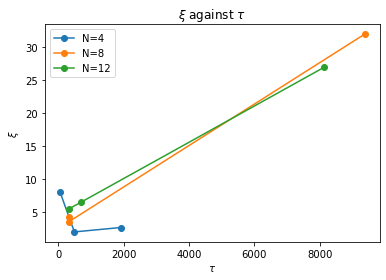

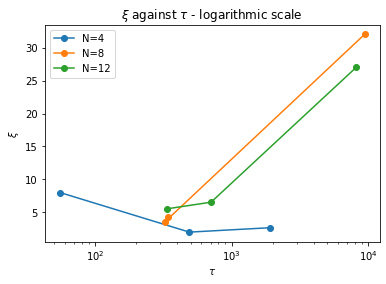

In [36]:

plt.plot(tau_4,xi_4, label = 'N=4', marker='o')
plt.plot(tau_8,xi_8, label = 'N=8', marker='o')
plt.plot(tau_12,xi_12, label = 'N=12', marker='o')
plt.xlabel(r'$\tau$')
plt.ylabel(r'$\xi$')
plt.title(r'$\xi$ against $\tau$')
plt.legend()
plt.show()
plt.plot(tau_4,xi_4, label = 'N=4', marker='o')
plt.plot(tau_8,xi_8, label = 'N=8', marker='o')
plt.plot(tau_12,xi_12, label = 'N=12', marker='o')
plt.xlabel(r'$\tau$')
plt.ylabel(r'$\xi$')
plt.title(r'$\xi$ against $\tau$ - logarithmic scale')
plt.xscale('log')
plt.legend()
plt.show()

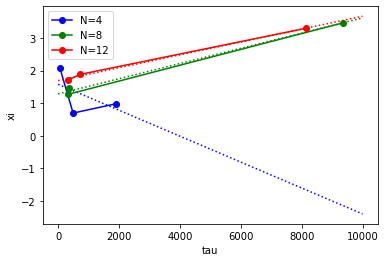

1.5758526082348296 1.2821740623262916 1.690963236060759


In [38]:
from scipy.optimize import curve_fit
def linear(x, a, b):
    return(a*x + b)

popt_xi_4, pcov_xi_4 = curve_fit(linear, tau_4[1:], np.log(xi_4[1:]))
z = np.linspace(0,10000,100000)
h_4 = linear(z, *popt_xi_4)
popt_xi_8, pcov_xi_8 = curve_fit(linear, tau_8[1:], np.log(xi_8[1:]))
h_8 = linear(z, *popt_xi_8)
popt_xi_12, pcov_xi_12 = curve_fit(linear, tau_12[1:], np.log(xi_12[1:]))
h_12 = linear(z, *popt_xi_12)

plt.plot(tau_4,np.log(xi_4), label = 'N=4', marker='o', color ='blue')
plt.plot(z, h_4, color ='blue', linestyle =':')
plt.plot(tau_8,np.log(xi_8), label = 'N=8', marker='o', color = 'green')
plt.plot(z, h_8, color = 'green', linestyle = ':')
plt.plot(tau_12,np.log(xi_12), label = 'N=12', marker='o', color = 'red')
plt.plot(z, h_12, color = 'red', linestyle =':')
plt.xlabel('tau')
plt.ylabel('xi')
#plt.yscale('log')
plt.legend()
plt.show()
print(popt_xi_4[1],popt_xi_8[1],popt_xi_12[1])

# z relation....